# **라이브러리 및 환경 설정**

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import pandas as pd
import os

# 1. 나눔 폰트 설치
!apt-get -qq -y install fonts-nanum > /dev/null

# 2. 설치된 폰트 파일의 절대 경로 확인
# 보통 코랩에서는 이 경로에 설치됩니다.
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

# 3. 폰트 매니저에 폰트 추가 및 설정
font_prop = fm.FontProperties(fname=font_path)
plt.rc('font', family=font_prop.get_name())
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 4. matplotlib 캐시 삭제 (중요: 이걸 해야 경고가 사라집니다)
!rm -rf ~/.cache/matplotlib

print(f"설정된 폰트 이름: {font_prop.get_name()}")

설정된 폰트 이름: NanumBarunGothic


In [ ]:
import warnings

# 1. 일반적인 파이썬 경고 무시
warnings.filterwarnings(action='ignore')

import matplotlib.pyplot as plt

# 2. matplotlib의 특정 폰트 관련 경고만 무시
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

In [ ]:
# 1. 나눔 폰트 설치
!sudo apt-get install -y fonts-nanum
!fc-cache -fv

# 2. matplotlib에 폰트 설정 적용
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

print("폰트 설치가 완료되었습니다. 상단 메뉴에서 [런타임] -> [세션 다시 시작]을 클릭한 후, 아래 2단계를 실행하세요!")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 런타임 재시작 후 다시 폰트 설정 (이 코드를 그래프 코드 맨 위에 붙여넣으세요)
plt.rc('font', family='NanumBarunGothic')

# 아까 작성한 시각화 코드 실행
# plot_pill_distribution(root_path)

# **데이터 불러오기**

데이터를 캐글에서 다운받아 구글 드라이브에 업로딩하였다



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import zipfile

zip_path = '/content/drive/MyDrive/data/ai09-level1-project.zip'
extract_path = '/content/dataset'

if not os.path.exists(extract_path):
  os.makedirs(extract_path)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
  zip_ref.extractall(extract_path)

# **데이터 EDA**

### **데이터 개수**

- 왜 test 이미지가 더 많지?



- 한 이미지 안에 4개의 알약이 있다

  - train(114) X 4 = 약 456개



In [ ]:
import os

base_path = '/content/dataset/sprint_ai_project1_data'

def count_files(dir_name):
    path = os.path.join(base_path, dir_name)
    if os.path.exists(path):
        return len(os.listdir(path))
    return 0

print(f"훈련용 이미지(train_images) 개수: {count_files('train_images')}")
print(f"테스트용 이미지(test_images) 개수: {count_files('test_images')}")

# annotations는 파일인지 폴더인지 확인
anno_path = os.path.join(base_path, 'train_annotations')
if os.path.isdir(anno_path):
    print(f"훈련용 어노테이션(train_annotations) 파일 개수: {len(os.listdir(anno_path))}")
else:
    print(f"훈련용 어노테이션 파일 존재 여부: {os.path.exists(anno_path)}")

훈련용 이미지(train_images) 개수: 232
테스트용 이미지(test_images) 개수: 842
훈련용 어노테이션(train_annotations) 파일 개수: 114


### **json 파일 수 확인**

json 파일과 train_images의 개수가 안 맞음

json과 images의 쌍을 만들어야 겠다

In [ ]:
import os
import json

base_path = '/content/dataset/sprint_ai_project1_data'
anno_root = os.path.join(base_path, 'train_annotations')

# 모든 하위 폴더에서 .json 파일 경로 수집
json_files = []
for root, dirs, files in os.walk(anno_root):
    for file in files:
        if file.endswith('.json'):
            json_files.append(os.path.join(root, file))

print(f"총 발견된 JSON 파일 개수: {len(json_files)}개")
print("첫 5개 파일 경로 샘플:")
for path in json_files[:5]:
    print(path)

총 발견된 JSON 파일 개수: 763개
첫 5개 파일 경로 샘플:
/content/dataset/sprint_ai_project1_data/train_annotations/K-003351-033880-035206_json/K-035206/K-003351-033880-035206_0_2_0_2_90_000_200.json
/content/dataset/sprint_ai_project1_data/train_annotations/K-003351-033880-035206_json/K-035206/K-003351-033880-035206_0_2_0_2_75_000_200.json
/content/dataset/sprint_ai_project1_data/train_annotations/K-003351-033880-035206_json/K-033880/K-003351-033880-035206_0_2_0_2_90_000_200.json
/content/dataset/sprint_ai_project1_data/train_annotations/K-003351-033880-035206_json/K-033880/K-003351-033880-035206_0_2_0_2_75_000_200.json
/content/dataset/sprint_ai_project1_data/train_annotations/K-003351-033880-035206_json/K-003351/K-003351-033880-035206_0_2_0_2_90_000_200.json


### **json 파일 풀기**

json 파일이 여러 폴더로 구분되어 있으므로 폴더 하나에 모든 json을 풀어 놓는다

In [ ]:
import os
import shutil
from tqdm import tqdm
import glob

# 1. 원본 폴더와 새로 만들 폴더 경로 설정
source_root = '/content/dataset/sprint_ai_project1_data/train_annotations' # 원본 위치
target_dir = '/content/dataset/sprint_ai_project1_data/train_jsons' # 모을 위치

# 2. 대상 폴더가 없으면 생성
if not os.path.exists(target_dir):
    os.makedirs(target_dir)
    print(f"폴더 생성 완료: {target_dir}")

# 3. 모든 하위 폴더에서 .json 파일 목록 가져오기
# **는 모든 하위 디렉토리를 의미합니다.
json_files = glob.glob(os.path.join(source_root, '**', '*.json'), recursive=True)

print(f"찾은 JSON 파일 개수: {len(json_files)}개")

# 4. 파일 복사 실행
copy_count = 0
for file_path in tqdm(json_files, desc="파일 복사 중"):
    file_name = os.path.basename(file_path) # 파일 이름만 추출
    target_path = os.path.join(target_dir, file_name)

    # 만약 파일 이름이 중복될 경우를 대비해 처리 (선택 사항)
    # AI Hub 데이터는 보통 파일명이 고유하지만, 혹시 모르니 체크합니다.
    if os.path.exists(target_path):
        # 중복 시 폴더명을 붙여서 이름 변경 (예: K-001_p01.json)
        parent_name = os.path.basename(os.path.dirname(file_path))
        target_path = os.path.join(target_dir, f"{parent_name}_{file_name}")

    shutil.copy(file_path, target_path)
    copy_count += 1

print(f"총 {copy_count}개의 파일이 '{target_dir}' 폴더로 복사되었습니다.")

찾은 JSON 파일 개수: 763개


파일 복사 중: 100%|██████████| 763/763 [00:00<00:00, 4687.52it/s]

총 763개의 파일이 '/content/dataset/sprint_ai_project1_data/train_jsons' 폴더로 복사되었습니다.


### **json 파일 중 필요한 정보가 뭐가 있을까?**

In [ ]:
import os
import json
import random

# JSON 파일들이 모인 경로
json_dir = '/content/dataset/sprint_ai_project1_data/train_jsons'
json_files = [f for f in os.listdir(json_dir) if f.endswith('.json')]

if json_files:
    # 샘플 하나 선택
    sample_name = random.choice(json_files)
    sample_path = os.path.join(json_dir, sample_name)

    with open(sample_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    print(f"📄 파일명: {sample_name}")
    print("-" * 50)
    # indent=4로 보기 좋게 출력, ensure_ascii=False로 한글 유지
    print(json.dumps(data, indent=4, ensure_ascii=False))
    print("-" * 50)
else:
    print("해당 경로에 JSON 파일이 없습니다.")

📄 파일명: K-036637_K-003351-036637-041768_0_2_0_2_90_000_200.json
--------------------------------------------------
{
    "images": [
        {
            "file_name": "K-003351-036637-041768_0_2_0_2_90_000_200.png",
            "width": 976,
            "height": 1280,
            "imgfile": "K-003351-036637-041768_0_2_0_2_90_000_200.png",
            "drug_N": "K-036637",
            "drug_S": "정상알약",
            "back_color": "연회색 배경",
            "drug_dir": "앞면",
            "light_color": "주백색",
            "camera_la": 90,
            "camera_lo": 0,
            "size": 200,
            "dl_idx": "36637",
            "dl_mapping_code": "K-036637",
            "dl_name": "로수젯정10/5밀리그램",
            "dl_name_en": "Rosuzet Tab. 10/5mg",
            "img_key": "http://connectdi.com/design/img/drug/147427082737900159.jpg",
            "dl_material": "로수바스타틴칼슘|에제티미브",
            "dl_material_en": "Ezetimibe| Rosuvastatin Calcium",
            "dl_custom_shape": "정제, 저작정",
            



```
"images": [
    {
        // --- 파일 및 규격 정보 ---
        "file_name": "K-003351...png",     // 물리적인 이미지 파일명
        "width": 976,                     // 이미지 가로 해상도 (pixel)
        "height": 1280,                   // 이미지 세로 해상도 (pixel)
        "imgfile": "K-003351...png",     // 이미지 원본 파일명 (위와 동일)
        "id": 309,                        // 이미지 고유 ID (어노테이션과 연결됨)

        // --- 촬영 환경 정보 (EDA 및 증강 전략용) ---
        "back_color": "연회색 배경",        // 배경색 (배경 다양성 확인용)
        "light_color": "주백색",           // 조명 색온도 (색감 왜곡 보정용)
        "camera_la": 90,                  // 카메라 수직 각도 (90도=정면)
        "camera_lo": 0,                   // 카메라 수평 각도
        "size": 200,                      // 촬영 시 피사체와의 거리/스케일 관련 수치

        // --- 약제 기본 식별 정보 ---
        "drug_N": "K-036637",             // 약제 식별 번호
        "drug_S": "정상알약",              // 알약 상태 (파손/정상 구분)
        "drug_dir": "앞면",                // 알약의 촬영 방향 (앞/뒤/옆)
        "dl_idx": "36637",                // 약제 인덱스 번호
        "dl_mapping_code": "K-036637",    // 매핑용 코드
        "dl_name": "로수젯정10/5밀리그램",   // 제품명 (한글)
        "dl_name_en": "Rosuzet Tab. 10/5mg", // 제품명 (영어)
        "img_key": "http://...",          // 원본 DB 이미지 링크
        "dl_company": "한미약품(주)",       // 제조사 명칭
        "dl_company_en": "Hanmi Pharm",   // 제조사 명칭 (영어)
        "item_seq": 201503658,            // 식약처 품목 일련번호

        // --- 의약품 허가 및 분류 정보 ---
        "di_item_permit_date": "20150608", // 품목 허가 일자
        "di_class_no": "[02180]동맥경화용제", // 식약처 분류 번호 및 명칭
        "di_etc_otc_code": "전문의약품",     // 전문/일반 의약품 구분
        "di_edi_code": "643507280",        // 보험코드 (EDI)
        "dl_material": "로수바스타틴...",     // 주요 성분 (한글)
        "dl_material_en": "Ezetimibe...",  // 주요 성분 (영어)

        // --- 외형 상세 특징 (컴퓨터 비전 핵심 정보) ---
        "chart": "이 약은 연한 노란색의...",  // 전문가의 육안 관찰 소견
        "drug_shape": "타원형",             // 약의 기하학적 모양
        "dl_custom_shape": "정제, 저작정",   // 제형 구분 (먹는 형태)
        "form_code_name": "필름코팅정",       // 알약 코팅 종류
        "thick": 4.02,                    // 알약 두께 (mm)
        "leng_long": 11,                  // 장축 길이 (mm)
        "leng_short": 6,                  // 단축 길이 (mm)
        "color_class1": "노랑",            // 주된 색상
        "color_class2": "",               // 보조 색상 (없을 경우 공백)

        // --- 각인 및 식별 표시 (OCR/미세 특징용) ---
        "print_front": "R5",              // 앞면 인쇄/각인 문자
        "print_back": "분할선",            // 뒷면 인쇄/각인 문자
        "line_front": "",                 // 앞면 분할선 유무
        "line_back": "-",                 // 뒷면 분할선 유무 (-)
        "mark_code_front_anal": "",       // 앞면 마크 분석 코드
        "mark_code_back_anal": "",        // 뒷면 마크 분석 코드

        // --- 기타 시스템 정보 ---
        "img_regist_ts": "20150728",      // 이미지 등록 날짜
        "change_date": "20190805"         // 정보 수정 날짜
    }
]
```


```
"annotations": [
    {
        "id": 1150,             // 어노테이션 자체의 고유 ID
        "image_id": 309,        // 위의 images -> id와 매칭됨 (309번 이미지의 정답)
        "category_id": 36637,   // 약의 클래스 ID (로수젯정 = 36637)
        "area": 47872,          // 바운딩 박스의 면적 (Pixel^2)
        "bbox": [
            161,                // x_min: 박스 시작점의 가로 좌표
            801,                // y_min: 박스 시작점의 세로 좌표
            187,                // width: 박스의 가로 폭
            256                 // height: 박스의 세로 높이
        ],
        "iscrowd": 0,           // 0이면 단일 객체, 1이면 객체 무리 (알약은 보통 0)
        "ignore": 0,            // 1이면 학습에서 제외할 데이터 (보통 0)
        "segmentation": []      // 폴리곤 좌표 (비어있으므로 BBox 기반 Detection 전용)
    }
]
```



```
"categories": [
    {
        "id": 36637,            // annotations의 category_id와 연결
        "name": "로수젯정...",    // 실제 클래스 이름
        "supercategory": "pill" // 상위 범주 (모두 pill로 동일)
    }
]
```








### **필수 정보**

필요한 정보는 annotations

In [ ]:
import os
import json
import random

# JSON 파일들이 모여 있는 경로
json_dir = '/content/dataset/sprint_ai_project1_data/train_jsons'
json_files = [f for f in os.listdir(json_dir) if f.endswith('.json')]

if json_files:
    # 무작위 샘플 선택
    sample_name = random.choice(json_files)
    sample_path = os.path.join(json_dir, sample_name)

    with open(sample_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    print(f"📄 현재 분석 중인 파일: {sample_name}")
    print("="*40)

    # 주요 정보 추출
    img_info = data['images'][0]
    print(f"1. 이미지 파일명: {img_info.get('file_name')}")
    print(f"2. 약제 이름(한글): {img_info.get('dl_name')}")
    print(f"3. 이미지 크기: {img_info.get('width')} x {img_info.get('height')}")

    # 좌표 정보 확인
    if 'annotations' in data:
        ann = data['annotations'][0]
        print(f"4. 바운딩 박스(bbox) 샘플: {ann.get('bbox')} (x, y, w, h)")

    print("="*40)
    # 전체 구조를 보고 싶다면 아래 주석 해제
    # print(json.dumps(data, indent=4, ensure_ascii=False))
else:
    print("폴더에 JSON 파일이 없습니다.")

📄 현재 분석 중인 파일: K-038162_K-003351-038162-041768_0_2_0_2_70_000_200.json
1. 이미지 파일명: K-003351-038162-041768_0_2_0_2_70_000_200.png
2. 약제 이름(한글): 로수바미브정 10/20mg
3. 이미지 크기: 976 x 1280
4. 바운딩 박스(bbox) 샘플: [584, 270, 188, 301] (x, y, w, h)


In [ ]:
import json
import glob

# 아까 찾은 파일 중 하나만 열어봅니다.
sample_json = glob.glob('/content/dataset/sprint_ai_project1_data/train_annotations/**/*.json', recursive=True)[0]

with open(sample_json, 'r', encoding='utf-8') as f:
    data = json.load(f)
    print("--- JSON 최상위 키 목록 ---")
    print(data.keys())
    print("\n--- 데이터 샘플 (첫 500글자) ---")
    print(str(data)[:500]) # 구조 파악을 위해 일부 출력

--- JSON 최상위 키 목록 ---
dict_keys(['images', 'type', 'annotations', 'categories'])

--- 데이터 샘플 (첫 500글자) ---
{'images': [{'file_name': 'K-003351-033880-035206_0_2_0_2_90_000_200.png', 'width': 976, 'height': 1280, 'imgfile': 'K-003351-033880-035206_0_2_0_2_90_000_200.png', 'drug_N': 'K-035206', 'drug_S': '정상알약', 'back_color': '연회색 배경', 'drug_dir': '앞면', 'light_color': '주백색', 'camera_la': 90, 'camera_lo': 0, 'size': 200, 'dl_idx': '35206', 'dl_mapping_code': 'K-035206', 'dl_name': '아토젯정 10/40mg', 'dl_name_en': 'Atozet Tab. 10/40mg', 'img_key': 'http://connectdi.com/design/img/drug/1NVzhGcz6U5.jpg', 'dl_


### **데이터 시각화**

- 데이터 자체가 스튜디오 환경에서 촬영된 경우가 많아 데이터 증강을 사용해야 할 것 같다
  - 기하학적 변환:
    - Rotation & Flip: 회전, 좌우/상하 반전
    - Shear & Perspective: 원금감을 주는 변환 (?)
  - 색상 및 조명:
    - Brightness & Contrast: 조명 조건에 대응하기 위해 조절
    - CLAHE: 알약 표면의 각인(문자)을 더 뚜렷하게 만듬
    

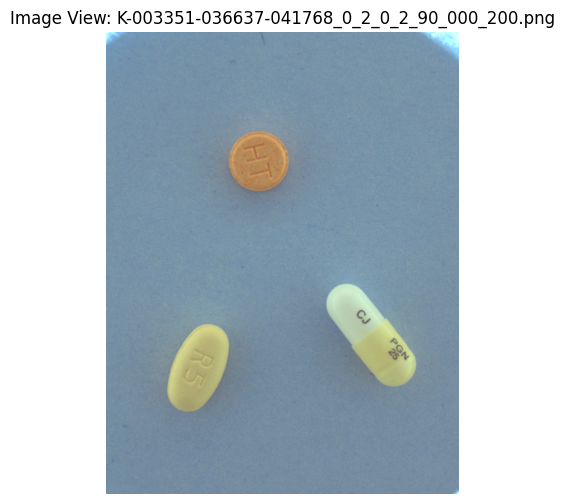

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import glob

# 위에서 선택된 sample_name과 data를 그대로 사용한다고 가정
if 'data' in locals():
    img_name = data['images'][0]['file_name']
    image_base_dir = '/content/dataset/sprint_ai_project1_data/train_images'

    # 이미지 찾기
    img_found = glob.glob(os.path.join(image_base_dir, '**', img_name), recursive=True)

    if img_found:
        img = Image.open(img_found[0])
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.title(f"Image View: {img_name}")
        plt.axis('off')
        plt.show()
    else:
        print(f"매칭되는 이미지를 {image_base_dir} 내에서 찾을 수 없습니다.")

비슷한 크기이고 모양인 약들이 많아서 글자나 그림 등이 중요하게 작용할 것 같다.

좀 더 명확하게 보이도록 전치리가 필요하다.

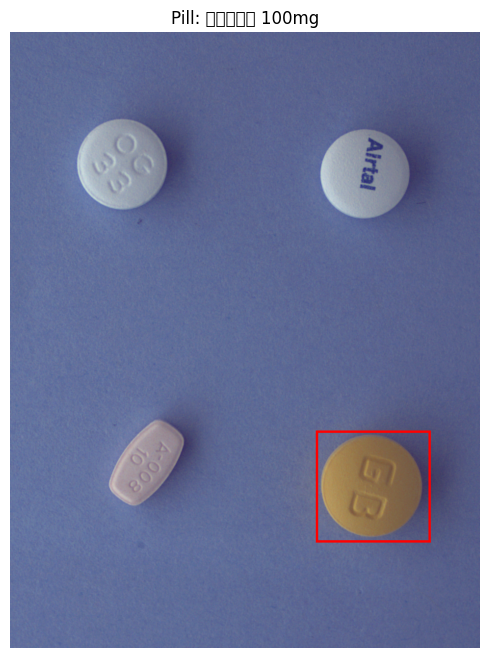

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import glob
import warnings

# 경고 무시
warnings.filterwarnings("ignore")

def simple_visualize(json_dir, image_root):
    # JSON 폴더에서 무작위 선택
    json_files = [f for f in os.listdir(json_dir) if f.endswith('.json')]
    sample_json = random.choice(json_files)

    with open(os.path.join(json_dir, sample_json), 'r', encoding='utf-8') as f:
        data = json.load(f)

    # 1. JSON에서 이미지 파일명 획득
    img_name = data['images'][0]['file_name']

    # 2. 이미지 루트 폴더 아래에서 해당 파일 찾기 (이미지는 아직 여러 폴더에 나뉘어 있을 수 있음)
    img_found = glob.glob(os.path.join(image_root, '**', img_name), recursive=True)

    if not img_found:
        print(f"❌ 이미지를 찾을 수 없습니다: {img_name}")
        return

    # 3. 이미지 열기 및 그리기
    img = Image.open(img_found[0])
    draw = ImageDraw.Draw(img)

    # 4. 박스 그리기
    for ann in data.get('annotations', []):
        if 'bbox' in ann:
            x, y, w, h = ann['bbox']
            # PIL: [x0, y0, x1, y1]
            draw.rectangle([x, y, x + w, y + h], outline="red", width=5)

    # 5. 결과 출력
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"Pill: {data['images'][0].get('dl_name', 'Unknown')}")
    plt.axis('off')
    plt.show()

# 실행
json_target_dir = '/content/dataset/sprint_ai_project1_data/train_jsons'
image_base_dir = '/content/dataset/sprint_ai_project1_data/train_images'

simple_visualize(json_target_dir, image_base_dir)

🧪 테스트 중인 이미지: /content/dataset/sprint_ai_project1_data/train_images/K-003483-025367-027733-029667_0_2_0_2_75_000_200.png


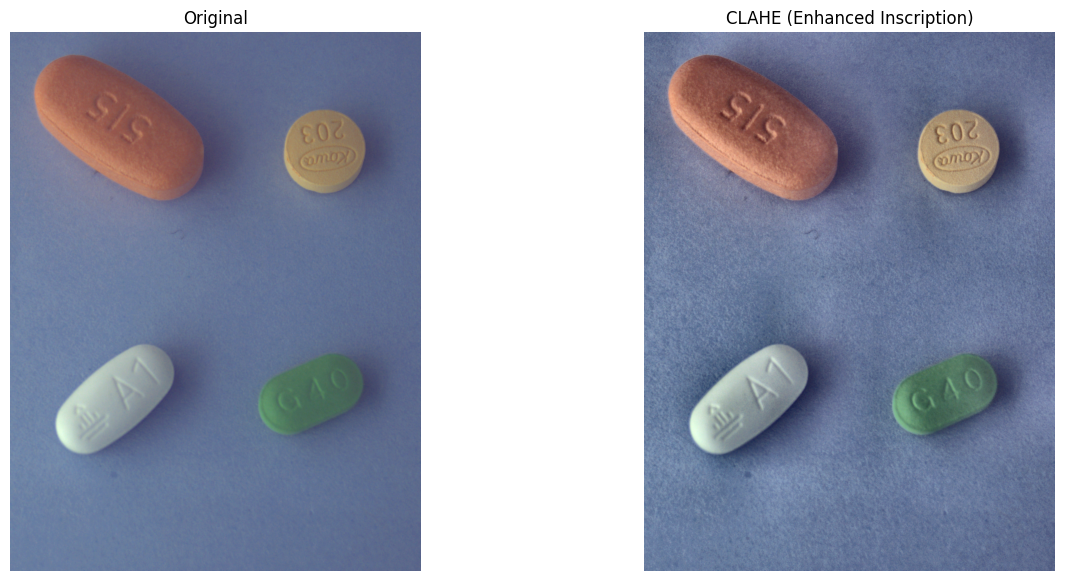

In [ ]:
import cv2
import numpy as np
import os
import glob
import random
from matplotlib import pyplot as plt

# 1. 경로 설정 (사용자님의 실제 환경에 맞게 수정됨)
image_base_dir = '/content/dataset/sprint_ai_project1_data/train_images'

def apply_clahe_to_image(image_path, clip_limit=2.0, tile_grid_size=(8, 8)):
    # 이미지 로드
    img = cv2.imread(image_path)

    # [에러 방지] 이미지를 못 읽었을 경우 처리
    if img is None:
        print(f"❌ 이미지를 불러올 수 없습니다: {image_path}")
        return None, None

    # 컬러 공간 변환 (BGR -> LAB)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # CLAHE 적용 (L 채널)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    cl = clahe.apply(l)

    # 채널 합치기 및 변환
    limg = cv2.merge((cl, a, b))
    final_img = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

    return img, final_img

# 2. 이미지 폴더에서 무작위로 하나 선택해서 테스트
# 하위 폴더까지 뒤져서 이미지 파일 리스트 확보
test_images = glob.glob(os.path.join(image_base_dir, '**/*.png'), recursive=True) + \
              glob.glob(os.path.join(image_base_dir, '**/*.jpg'), recursive=True)

if not test_images:
    print("❌ 이미지 폴더가 비어있거나 경로가 잘못되었습니다.")
else:
    sample_path = random.choice(test_images) # 무작위 1개 선택
    print(f"🧪 테스트 중인 이미지: {sample_path}")

    original, enhanced = apply_clahe_to_image(sample_path)

    # 3. 결과 시각화
    if enhanced is not None:
        plt.figure(figsize=(15, 7))

        plt.subplot(1, 2, 1)
        plt.title("Original")
        plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.title("CLAHE (Enhanced Inscription)")
        plt.imshow(cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB))
        plt.axis('off')

        plt.show()

### **약제 클래스 분포 확인**
- 클래스 불균형
- 특정 클래스가 엄청 많음으로 클래스 균형을 고려하여 학습해야 할 것 같다

데이터 읽는 중: 100%|██████████| 995/995 [00:00<00:00, 8806.86it/s]


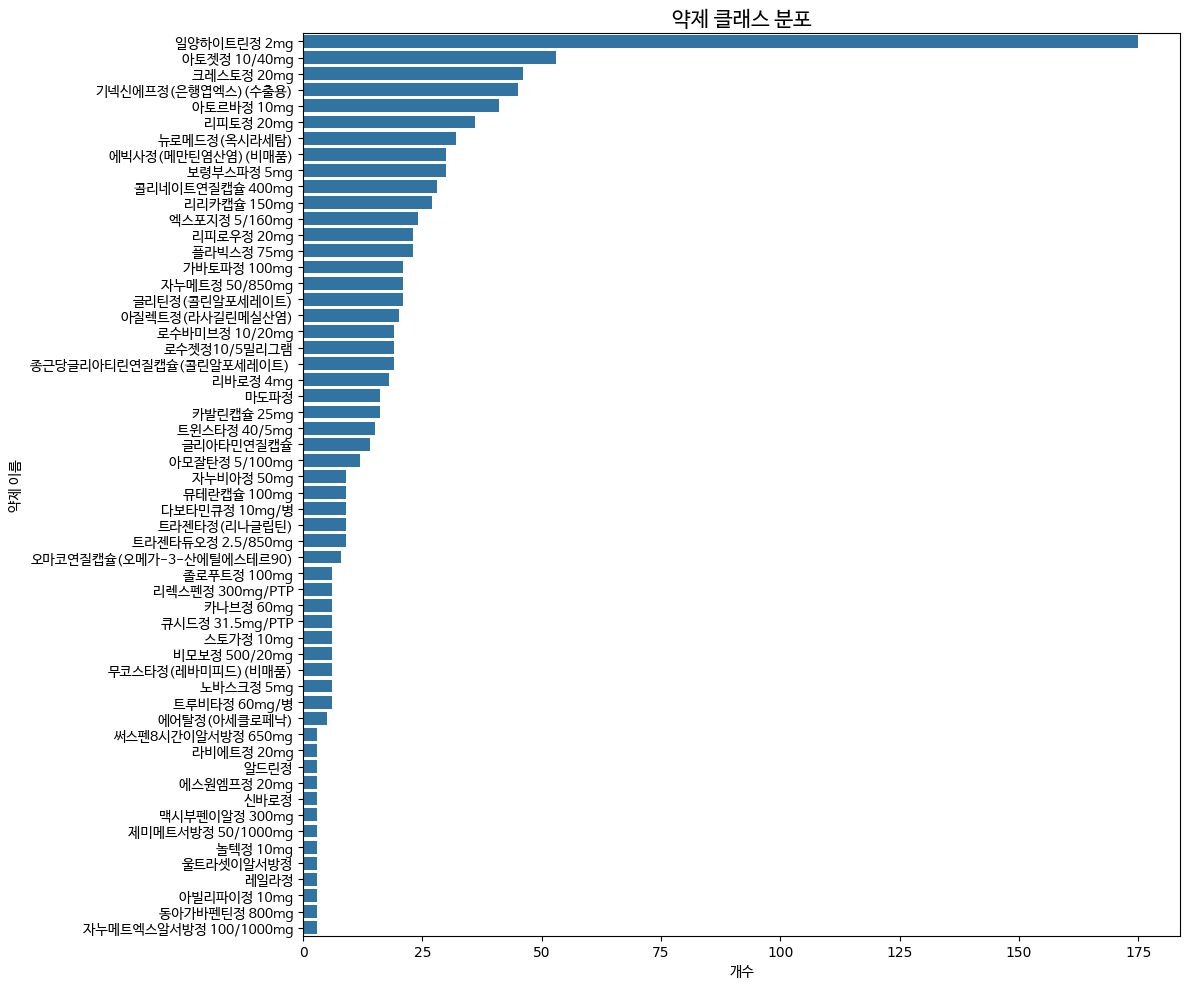

In [ ]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import glob

def plot_pill_distribution(root_dir):
    pill_names = []

    # 하위 폴더의 모든 JSON 파일 찾기
    json_files = glob.glob(os.path.join(root_dir, '**', '*.json'), recursive=True)

    for path in tqdm(json_files, desc="데이터 읽는 중"):
        with open(path, 'r', encoding='utf-8') as f:
            try:
                data = json.load(f)
                # 샘플 확인 결과: data['images']가 리스트 형태이고 그 안에 'dl_name'이 있음
                if 'images' in data and len(data['images']) > 0:
                    pill_name = data['images'][0].get('dl_name', 'Unknown')
                    pill_names.append(pill_name)
            except Exception as e:
                pass # 에러 발생 파일은 건너뜀

    if not pill_names:
        print("데이터를 추출하지 못했습니다. 경로를 확인해주세요.")
        return

    df = pd.DataFrame(pill_names, columns=['Pill_Name'])

    plt.figure(figsize=(12, 10))

    # sns.countplot 대신 직접 그리기 (폰트 지정이 더 쉬움)
    ax = sns.countplot(data=df, y='Pill_Name', order=df['Pill_Name'].value_counts().index)

    # 축 이름과 제목에 폰트 직접 적용
    plt.title('약제 클래스 분포', fontproperties=font_prop, fontsize=15)
    plt.xlabel('개수', fontproperties=font_prop)
    plt.ylabel('약제 이름', fontproperties=font_prop)

    # Y축 레이블(약 이름) 각각에 폰트 적용
    for label in ax.get_yticklabels():
        label.set_fontproperties(font_prop)

    plt.tight_layout()
    plt.show()

# 사용 예시
plot_pill_distribution('/content/dataset/sprint_ai_project1_data/train_jsons')

### **전체 이미지 대비 객체 비율**

- 객체의 비율이 전체 이미지 대비 작으므로 고해상도를 유지하는 게 좋을 것 같다


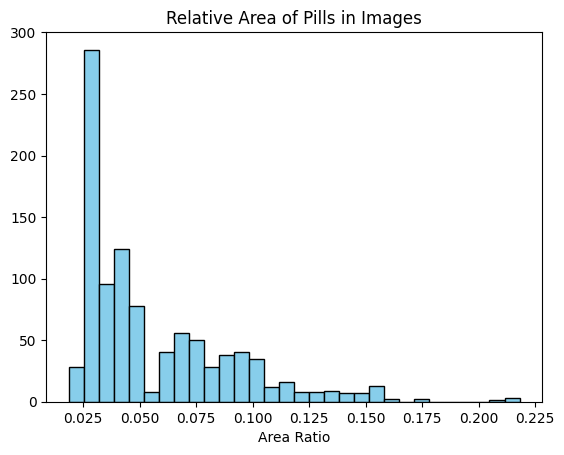

In [ ]:
def analyze_bbox_size(json_dir):
    widths, heights, areas = [], [], []
    for file in os.listdir(json_dir):
        if file.endswith('.json'):
            with open(os.path.join(json_dir, file), 'r') as f:
                data = json.load(f)
                img_w, img_h = data['images'][0]['width'], data['images'][0]['height']
                for ann in data['annotations']:
                    _, _, w, h = ann['bbox']
                    widths.append(w / img_w) # 정규화된 가로
                    heights.append(h / img_h) # 정규화된 세로
                    areas.append((w * h) / (img_w * img_h)) # 면적 비율

    # 히스토그램 시각화
    plt.hist(areas, bins=30, color='skyblue', edgecolor='black')
    plt.title('Relative Area of Pills in Images')
    plt.xlabel('Area Ratio')
    plt.show()

analyze_bbox_size('/content/dataset/sprint_ai_project1_data/train_jsons')

# **전처리 하면 좋을 것**

### **코드잇 측 요구사항**
- 각 로우에는 image_id에 매핑되는 객체 1개가 들어갑니다
- image_id에 이미지 파일명의 숫자를 입력해 주세요
- image_id를 기준으로 채점이 되므로, annotation_id는 로우의 개수만큼 임의의 고유한 값들로 설정해 주세요



```
annotation_id, image_id, category_id, bbox_x, bbox_y, bbox_w, bbox_h, score
1, 1, 1, 156, 247, 211, 456, 0.91
2, 1, 24, 498, 40, 460, 474, 0.78
3, 1, 11, 579, 700, 260, 473, 0.27
4, 1, 69, 527, 83, 398, 416, 0.27
5, 3, 1, 143, 236, 204, 135, 0.89
6, 3, 24, 512, 41, 388, 432, 0.78
7, 3, 11, 556, 677, 257, 435, 0.20
...
```




In [ ]:
import os
import re
import pandas as pd

def create_mapping_table(image_dir):
    mapping_list = []
    image_files = [f for f in os.listdir(image_dir) if f.endswith(('.png', '.jpg'))]

    for img_name in image_files:
        # 파일명에서 숫자만 추출 (예: 'abc_123.png' -> 123)
        # 프로젝트의 파일명 규칙에 따라 정규표현식을 수정하세요.
        numbers = re.findall(r'\d+', img_name)
        if numbers:
            img_id = int(numbers[-1]) # 보통 마지막 숫자가 ID인 경우가 많음
        else:
            img_id = 0 # 예외 처리

        mapping_list.append({'file_name': img_name, 'image_id': img_id})

    return pd.DataFrame(mapping_list)

# 실행 예시
# df_mapping = create_mapping_table('/content/dataset/train_images')
# df_mapping.to_csv('image_id_mapping.csv', index=False)

# **모델**

### **2-stage detector (높은 정확도)**
- R-CNN
- Fast R-CNN
- Faster R-CNN

### **1-stage detector (빠른 실시간 탐지)**
- yolo
- ssd
- retinaNet


### **가장 성능이 좋게 나올 것으로 예상되는 모델**

최근 논문과 대회 기준
- YOLO11/YOLO10 (최신 YOLO 시리즈)
- RT-DETR (CNN 방식이 아닌 Transformer 구조 사용)
- DINO (속도보다는 오직 정확도(mAP)만 따졌을 때 최고의 성능)

앙상블도 생각해보면 좋을 듯
